In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
import sys
import json
import psycopg2
from langdetect import detect, DetectorFactory

# On fixe la graine de langdetect pour des résultats reproductibles
DetectorFactory.seed = 42 

# Importation de notre modèle
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.mlp_numpy import MLP

print("Bibliothèques chargées avec succès !")

Bibliothèques chargées avec succès !


In [2]:
print("=== Récupération du jeu de test ===")

# 1. Chargement des vecteurs et du mapping
X_test = np.load("../donnees/features/X_test.npy")
y_test = np.load("../donnees/features/y_test.npy")

with open("../donnees/features/mapping_langues.json", "r") as f:
    mapping = json.load(f)
langues_inverse = {v: k for k, v in mapping.items()}
labels_noms = [langues_inverse[i] for i in range(len(mapping))]

# 2. Récupération des textes depuis PostgreSQL
conn = psycopg2.connect(dbname="langdetect_projet", user="langdetect_user", password="motdepasse", host="localhost", port="5432")
df_textes = pd.read_sql("SELECT contenu FROM documents ORDER BY langue", conn)
tous_les_textes = df_textes['contenu'].tolist()
conn.close()

# 3. On reproduit la séparation exacte (seed=42)
np.random.seed(42)
indices = np.random.permutation(len(tous_les_textes))
n_train = int(len(tous_les_textes) * 0.70)
n_val = int(len(tous_les_textes) * 0.15)
idx_test = indices[n_train + n_val:]

textes_test = [tous_les_textes[i] for i in idx_test]

print(f"Prêt ! {len(X_test)} vecteurs chargés avec leurs {len(textes_test)} textes bruts correspondants.")
print(f"Langues évaluées : {labels_noms}")

=== Récupération du jeu de test ===
Prêt ! 600 vecteurs chargés avec leurs 600 textes bruts correspondants.
Langues évaluées : ['ar', 'de', 'en', 'es', 'fr', 'nl', 'pt', 'ru']


/tmp/ipykernel_96382/317598517.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_textes = pd.read_sql("SELECT contenu FROM documents ORDER BY langue", conn)


=== Évaluation du Modèle NumPy (Fait main) ===
Modèle chargé : ../modeles/mlp_final.npz

--- Précision par langue ---
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00        62
          de       0.94      0.99      0.96        80
          en       0.99      1.00      0.99        75
          es       0.99      0.92      0.95        78
          fr       1.00      1.00      1.00        63
          nl       1.00      0.92      0.96        77
          pt       0.92      0.99      0.95        82
          ru       1.00      1.00      1.00        83

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



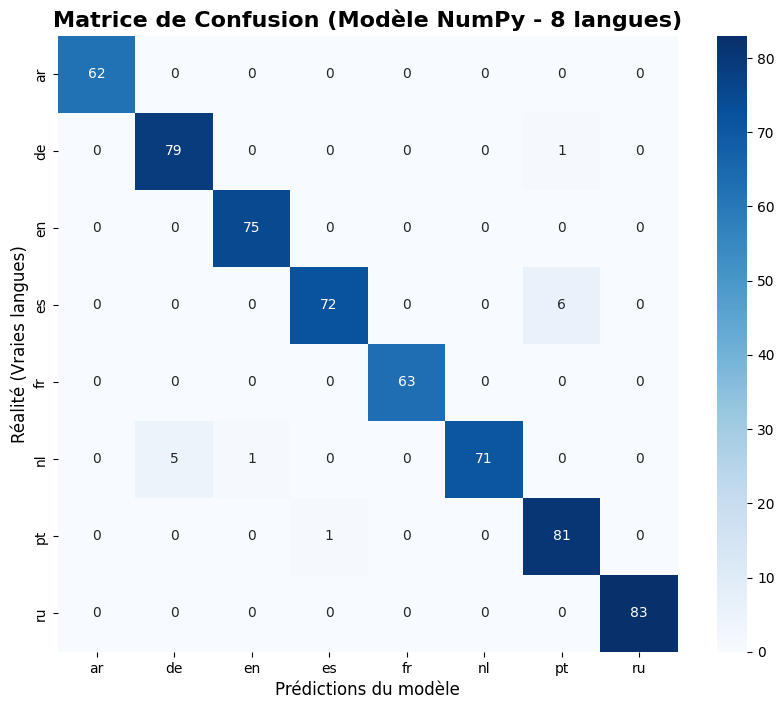

In [3]:
print("=== Évaluation du Modèle NumPy (Fait main) ===")

# Chargement du modèle
modele_numpy = MLP(n_entree=X_test.shape[1], n_classes=len(mapping))
modele_numpy.charger("../modeles/mlp_final.npz")

# Prédictions
y_pred_np = modele_numpy.predict(X_test)

# 1. Accuracy globale et par langue (Classification report)
print("\n--- Précision par langue ---")
print(classification_report(y_test, y_pred_np, target_names=labels_noms))

# 2. Matrice de confusion
cm = confusion_matrix(y_test, y_pred_np)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_noms, yticklabels=labels_noms)
plt.title('Matrice de Confusion (Modèle NumPy - 8 langues)', fontsize=16, fontweight='bold')
plt.xlabel('Prédictions du modèle', fontsize=12)
plt.ylabel('Réalité (Vraies langues)', fontsize=12)

# Sauvegarde pour le rapport final
plt.savefig('matrice_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

In [4]:
print("=== Lancement de la Baseline (langdetect) ===")
y_pred_ld = []

# langdetect analyse le texte brut, phrase par phrase
for texte in textes_test:
    try:
        prediction = detect(texte)
        # langdetect retourne 'ar', 'en', etc.
        y_pred_ld.append(prediction)
    except:
        # langdetect plante parfois si le texte est trop bizarre (ex: que des chiffres)
        y_pred_ld.append("erreur")

# Conversion de nos vraies étiquettes (0, 1, 2...) en texte ('ar', 'de'...)
y_test_str = [langues_inverse[idx] for idx in y_test]

# Calcul du score langdetect
correct_ld = sum(1 for vrai, pred in zip(y_test_str, y_pred_ld) if vrai == pred)
acc_ld = correct_ld / len(y_test_str)
acc_np = np.mean(y_test == y_pred_np)

df_bilan = pd.DataFrame({
    "Système évalué": ["Notre MLP NumPy", "langdetect (Baseline Pro)"],
    "Accuracy sur le jeu de test": [f"{acc_np*100:.2f}%", f"{acc_ld*100:.2f}%"],
    "Textes corrects": [f"{int(acc_np * len(y_test))}/{len(y_test)}", f"{correct_ld}/{len(y_test)}"]
})

print("\nCLASSEMENT FINAL SUR LE JEU DE TEST")
display(df_bilan)

=== Lancement de la Baseline (langdetect) ===

CLASSEMENT FINAL SUR LE JEU DE TEST


,Système évalué,Accuracy sur le jeu de test,Textes corrects
0,Notre MLP NumPy,97.67%,586/600
1,langdetect (Baseline Pro),99.83%,599/600


In [5]:
print("=== Analyse des erreurs de notre modèle ===")
erreurs_indices = np.where(y_test != y_pred_np)[0]

if len(erreurs_indices) == 0:
    print("Incroyable ! Le modèle n'a fait absolument aucune erreur sur le jeu de test.")
else:
    print(f"Le modèle s'est trompé sur {len(erreurs_indices)} textes sur {len(y_test)}.\n")
    
    # On affiche les 5 premières erreurs pour comprendre
    for idx in erreurs_indices[:5]:
        vrai = langues_inverse[y_test[idx]].upper()
        pred = langues_inverse[y_pred_np[idx]].upper()
        
        # Extrait propre (sans retours à la ligne)
        extrait = textes_test[idx][:300].replace('\n', ' ') 
        
        print(f"Vraie langue : {vrai} | Prédite comme : {pred}")
        print(f"   Extrait : \"{extrait}...\"\n")

=== Analyse des erreurs de notre modèle ===
Le modèle s'est trompé sur 14 textes sur 600.

Vraie langue : ES | Prédite comme : PT
   Extrait : "Italia estuvo representada en los Juegos Paralímpicos de Nueva York y Stoke Mandeville 1984 por un total de 60 deportistas, 47 hombres y 13 mujeres. Medallistas. El equipo paralímpico italiano obtuvo las siguientes medallas:..."

Vraie langue : NL | Prédite comme : DE
   Extrait : "Domingos Elias Alves Pedra (Paraíba do Sul, 16 april 1948) is een voormalig Braziliaanse voetballer en trainer, beter bekend onder zijn spelersnaam Dé. In 1974 werd hij landskampioen met Vasco da Gama. Biografie. Dé begon zijn carrière bij Bangu en maakte in 1970 de overstap naar Vasco da Gama, waar..."

Vraie langue : NL | Prédite comme : DE
   Extrait : "Asterophora is een geslacht van schimmels behorend tot de familie Lyophyllaceae. De geslachtnaam werd gepubliceerd in 1809 beschreven door Ludwig Peter Friedrich Ditmar.  Soorten. Volgens Index Fungorum telt dit ge